In [1]:
!pip install -q opencv-contrib-python

In [2]:
!pip install -q ai-accelerator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.4/220.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.0/233.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.8/898.8 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install -q torchinfo

In [4]:
!pip show torchinfo

Name: torchinfo
Version: 1.8.0
Summary: Model summary in PyTorch, based off of the original torchsummary.
Home-page: https://github.com/tyleryep/torchinfo
Author: Tyler Yep @tyleryep
Author-email: tyep@cs.stanford.edu
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [5]:
!pip show opencv-contrib-python

Name: opencv-contrib-python
Version: 4.13.0.92
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy
Required-by: 


In [6]:
!pip show ai-accelerator

Name: ai-accelerator
Version: 1.1.2
Summary: AI Accelerator: A production-ready MLOps platform to deploy, monitor, and govern machine learning models with security, scalability, and auditability.
Home-page: https://github.com/AyoubArdem
Author: 
Author-email: Ayoub Ardem <ayoub.ardem@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: celery, Django, django-cors-headers, django-extensions, django-redis, djangorestframework, djangorestframework-simplejwt, docker, drf-spectacular, joblib, numpy, psycopg2-binary, PyJWT, python-decouple, python-dotenv, redis, requests, rich, scipy, typer
Required-by: 


In [7]:
import tarfile
import numpy
from pathlib import Path
import os
import matplotlib.pyplot as plt
import pickle
import random
import cv2 as cv
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as op
from torch.utils.data import DataLoader
from google.colab import files

In [8]:
folder = Path()
file_name = "output_dir"
path_imgs = folder / file_name
path_imgs.mkdir(parents=True,exist_ok=True,mode=700)

file_to_download = 'cifar-100-python.tar.gz'
download_url = 'https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz'

if not os.path.exists(os.path.join('/content/', file_to_download)):
    print(f'Downloading {file_to_download}...')
    !wget {download_url} -P /content/
    if os.path.exists(os.path.join('/content/', file_to_download)):
        print(f'Successfully downloaded {file_to_download}.')
    else:
        print(f'Download of {file_to_download} failed.')
else:
    print(f'{file_to_download} already exists in /content/. Skipping download.')

def unpickle(file_path):
    with open(file_path, 'rb') as fo:
        dict = pickle.load(fo, encoding='latin1')
    return dict

try :
  with tarfile.open("/content/cifar-100-python.tar.gz","r:gz") as tar:
     tar.extractall(path=path_imgs)

  # Explicitly load the train, test, and meta files after extraction
  cifar_path = path_imgs / "cifar-100-python"
  data_dict = unpickle(cifar_path / "train") # This will be the main data
  test_dict = unpickle(cifar_path / "test")
  meta_data_dict = unpickle(cifar_path / "meta") # Contains fine and coarse label names

  # Add meta information to data_dict
  data_dict['fine_label_names'] = meta_data_dict['fine_label_names']
  data_dict['coarse_label_names'] = meta_data_dict['coarse_label_names']

  print("CIFAR-100 train data loaded into data_dict.")
  print("CIFAR-100 test data loaded into test_dict.")
  print("CIFAR-100 meta data loaded into meta_data_dict and merged into data_dict.")

except Exception as e:
  print(f"Something went wrong during extraction or loading: {e}")
  print("Maybe you have uploaded /content/cifar-100-python.tar.gz to Google Colab directly, or the file is corrupted.")

--2026-04-07 11:34:14--  https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 169001437 (161M) [application/x-gzip]
Saving to: ‘/content/cifar-100-python.tar.gz’

cifar-100-python.ta 100%[===================>] 161.17M  45.0MB/s    in 4.0s    

2026-04-07 11:34:18 (40.5 MB/s) - ‘/content/cifar-100-python.tar.gz’ saved [169001437/169001437]

Successfully downloaded cifar-100-python.tar.gz.


/tmp/ipykernel_5807/1232191241.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=path_imgs)


CIFAR-100 train data loaded into data_dict.
CIFAR-100 test data loaded into test_dict.
CIFAR-100 meta data loaded into meta_data_dict and merged into data_dict.


In [9]:
data_dict.keys()

dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data', 'fine_label_names', 'coarse_label_names'])

In [10]:
print("INFO:\n")
print("A list of the actual filenames for the images: ")
print(f"FILENAMES : {set(data_dict["filenames"])}")
print(f"NUMBER OF IMAGES : {len(set(data_dict["filenames"]))}")
print("\n")
print("A list of 100 specific class indices (0–99): ")
print(f"FINE_LABEL : {set(data_dict["fine_labels"])}")
print("\n")
print("A list of 20 superclass indices (0–19): ")
print(f"COARSE_LABELS : {set(data_dict["coarse_labels"])}")
print("\n")
print(f"DATA SHAPE : {data_dict["data"].shape}")
print(f" 3072 is the shape of a single CIFAR-100 image when it is \"flattened\" into a 1D vector.")
print("\n")
print(f"""This number comes from the product of the image's dimensions:
         Width: 32 pixels
         Height: 32 pixels
         Channels: 3 (Red, Green, Blue)\n
         Total Calculation: 32*32*3 = {32*32*3} """)



INFO:

A list of the actual filenames for the images: 
FILENAMES : {'baby_s_002418.png', 'guided_missile_s_001445.png', 'opossum_s_000195.png', 'boy_s_000059.png', 'timber_wolf_s_000732.png', 'squirrel_s_002287.png', 'atlantic_bottlenose_dolphin_s_000083.png', 'pickup_truck_s_000618.png', 'panthera_leo_s_000481.png', 'porcupine_s_002263.png', 'oxen_s_002044.png', 'palm_tree_s_002129.png', 'coluber_hippocrepis_s_000124.png', 'cichlid_fish_s_000441.png', 'gray_wolf_s_001212.png', 'breakfast_table_s_000858.png', 'lift_bridge_s_000286.png', 'timber_wolf_s_001433.png', 'hamster_s_002318.png', 'telephone_set_s_000756.png', 'dessert_plate_s_000434.png', 'skyscraper_s_001704.png', 'poppy_s_000565.png', 'shortfin_mako_s_000564.png', 'soda_bottle_s_000777.png', 'mouse_s_001087.png', 'butterfly_orchid_s_001346.png', 'maine_lobster_s_000002.png', 'helix_pomatia_s_000301.png', 'bear_s_000332.png', 'argiope_aurantia_s_000957.png', 'female_child_s_000205.png', 'butterfly_s_001624.png', 'cain_s_000251

The images are pixelated because the CIFAR-100 dataset is made up of very low-resolution images (32x32 pixels).
When these small images are displayed on a larger screen, each pixel of the original image is stretched,
which gives a pixelated look.This is an intentional feature of this dataset.



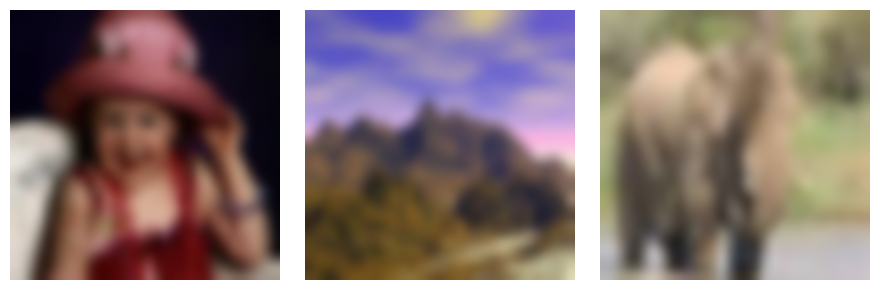

In [11]:

  # Reshape the 1D data (3072,) into (3, 32, 32) for channels, height, width
  # Then transpose it to (32, 32, 3) which is the expected format for matplotlib imshow
  # Pick 3 random indices
print("""The images are pixelated because the CIFAR-100 dataset is made up of very low-resolution images (32x32 pixels).
When these small images are displayed on a larger screen, each pixel of the original image is stretched,
which gives a pixelated look.This is an intentional feature of this dataset.\n""")

indices = random.sample(range(len(data_dict["data"])), k=3)
plt.figure(figsize=(9, 3))
for i, img_index in enumerate(indices):
    img = data_dict["data"][img_index].reshape(3, 32, 32).transpose(1, 2, 0)
    plt.subplot(1, 3, i+1)
    plt.imshow(img,interpolation="bicubic")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0,translate=(0.1,0.1),scale=(0.8,1.5)),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),

])

In [13]:
print("""SIFT (Scale-Invariant Feature Transform) is a computer vision algorithm
used to detect and describe distinctive features in images that remain
stable under changes in scale, rotation, and illumination. """)

SIFT (Scale-Invariant Feature Transform) is a computer vision algorithm
used to detect and describe distinctive features in images that remain
stable under changes in scale, rotation, and illumination. 


In [14]:

ScaleInvariantFeatureTransform = {}
sift = cv.SIFT_create()

for img , path in zip(data_dict["data"],data_dict["filenames"]):
  # Reshape 1D data to HWC format for color image
  img_reshaped_transposed = img.reshape(3, 32, 32).transpose(1, 2, 0) # Shape: (32, 32, 3)

  # Convert to grayscale. cv.cvtColor expects HWC for color input.
  gray_img = cv.cvtColor(img_reshaped_transposed, cv.COLOR_BGR2GRAY) # Shape: (32, 32) uint8

  # Apply torchvision transforms.
  img_transformed_tensor = transform(gray_img)

  # Convert the PyTorch tensor back to a NumPy array for OpenCV's SIFT.
  # Squeeze the channel dimension and convert to uint8 (scaling from [0,1] to [0,255]).
  # SIFT typically works best with uint8 images.
  img_for_sift = (img_transformed_tensor.squeeze(0).numpy() * 255).astype(numpy.uint8) # (32, 32) uint8

  # Detect and compute SIFT features on the processed NumPy image
  keypoints , descriptor = sift.detectAndCompute(img_for_sift, None)

  ScaleInvariantFeatureTransform[path] = [keypoints,descriptor]
  if keypoints is not None and  descriptor is not None:
    print(f"Number of keypoints for image {path} : {len(keypoints)}")
    print(f"Descriptor shape for image {path} : {descriptor.shape}")
  else :
    print(f"No keypoints or descriptor found for image {path}")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Descriptor shape for image pickup_truck_s_001110.png : (12, 128)
Number of keypoints for image wood_s_000442.png : 9
Descriptor shape for image wood_s_000442.png : (9, 128)
Number of keypoints for image acer_saccharinum_s_001721.png : 7
Descriptor shape for image acer_saccharinum_s_001721.png : (7, 128)
Number of keypoints for image cirrocumulus_s_000945.png : 7
Descriptor shape for image cirrocumulus_s_000945.png : (7, 128)
Number of keypoints for image telephone_set_s_000780.png : 12
Descriptor shape for image telephone_set_s_000780.png : (12, 128)
Number of keypoints for image telephone_s_001935.png : 13
Descriptor shape for image telephone_s_001935.png : (13, 128)
Number of keypoints for image dromedary_s_001107.png : 13
Descriptor shape for image dromedary_s_001107.png : (13, 128)
Number of keypoints for image armoured_combat_vehicle_s_000373.png : 12
Descriptor shape for image armoured_combat_vehicle_s_

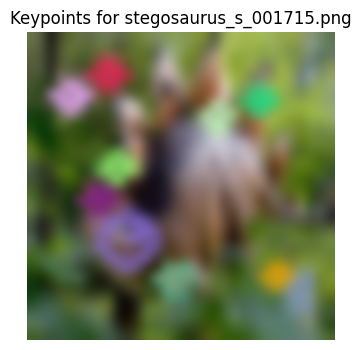

In [15]:
filename_to_display = random.choice(data_dict["filenames"])
keypoint, descriptor = ScaleInvariantFeatureTransform[filename_to_display]

# Find the index of the filename in data_dict["filenames"]
img_index = data_dict["filenames"].index(filename_to_display)

# Get the raw image data from data_dict
raw_img_data = data_dict["data"][img_index]

# Reshape the 1D data to (3, 32, 32) and then transpose to (32, 32, 3) for OpenCV/Matplotlib
img_to_draw = raw_img_data.reshape(3, 32, 32).transpose(1, 2, 0)

# Ensure the image data is uint8, which is expected by cv.drawKeypoints
img_to_draw = img_to_draw.astype(numpy.uint8)

# Draw keypoints on the reconstructed image
img_with_keypoints = cv.drawKeypoints(img_to_draw, keypoint, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the image with keypoints using matplotlib instead of cv.imshow
plt.figure(figsize=(4, 4))
plt.imshow(img_with_keypoints,interpolation="bicubic")
plt.title(f"Keypoints for {filename_to_display}")
plt.axis('off')
plt.show()

In [16]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
  """
    batch: list of samples from DataLoader. Each sample is a tuple: (filename, [keypoints, descriptor])
    return: (list of filenames, padded_batch of descriptors with shape (batch_size, max_num_keypoints, descriptor_dim))
  """
  filenames = [] # Store filenames
  descriptors_to_pad = []
  for filename , kp_desc_pair in batch: # kp_desc_pair is [keypoints_tuple, descriptor_ndarray]
    descriptor_ndarray = kp_desc_pair[1] # This extracts the actual numpy array (or None)
    filenames.append(filename) # Collect filename

    if descriptor_ndarray is not None:
      # Convert numpy array to torch tensor, ensure float32 type as SIFT descriptors are floats
      descriptors_to_pad.append(torch.from_numpy(descriptor_ndarray).float())
    else:
      # If an image has no descriptors (descriptor_ndarray is None), append an empty tensor
      # This ensures pad_sequence can still process the batch, and we don't drop samples.
      # The empty tensor should have the correct descriptor dimension (128 for SIFT).
      descriptors_to_pad.append(torch.empty(0, 128))

  # Pad the sequence of tensors to the max length in the batch
  padded_batch = pad_sequence(descriptors_to_pad, batch_first=True, padding_value=0.0)
  return filenames, padded_batch # Return both filenames and padded batch

dataset = DataLoader(list(ScaleInvariantFeatureTransform.items()), batch_size=32, collate_fn=collate_fn)

# To get a batch from the DataLoader, you need to iterate over it
# Get the first batch to inspect its shape
first_batch_filenames, first_batch_descriptors = next(iter(dataset))
print(f"first batch filenames (first 5): {first_batch_filenames[:5]}")
print(f"first batch descriptors shape: {first_batch_descriptors.shape}")

first batch filenames (first 5): ['bos_taurus_s_000507.png', 'stegosaurus_s_000125.png', 'mcintosh_s_000643.png', 'altar_boy_s_001435.png', 'cichlid_s_000031.png']
first batch descriptors shape: torch.Size([32, 23, 128])


In [17]:
class EmbedInvariantPrintDescriptor(nn.Module):
  def __init__(self):
    super().__init__()
    # Initialize linear layers for Q, K, V projections instead of fixed random tensors
    self.q_proj = nn.Linear(128, 128)
    self.k_proj = nn.Linear(128, 128)
    self.v_proj = nn.Linear(128, 128)

    self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=8, batch_first=False) # MultiheadAttention expects (seq_len, batch_size, embed_dim) by default
    self.noisestd = 0.1

    # Final feed-forward layers for processing the aggregated descriptor
    self.final_linear1 = nn.Linear(128, 256)
    self.relu = nn.ReLU()
    self.final_linear2 = nn.Linear(256, 128)
    self.batch_norm = nn.BatchNorm1d(128) # BatchNorm for (batch_size, num_features)

  def forward(self, x_batch): # x_batch has shape (batch_size, max_num_keypoints, 128)
    output_vectors = []
    for x in x_batch: # x for a single image has shape (num_keypoints, 128)

      if x.shape[0] == 0: # Handle images with no keypoints
          # Append a zero vector of the expected final dimension (256)
          output_vectors.append(torch.zeros(128, device=x.device)) # Changed output size to 128 here
          continue

      # Add noise for perturbation
      x_perturbed = x + torch.rand_like(x) * self.noisestd

      # Project x_perturbed into Query, Key, Value
      # Each projection will have shape (num_keypoints, 128)
      query = self.q_proj(x_perturbed)
      key = self.k_proj(x_perturbed)
      value = self.v_proj(x_perturbed)

      # MultiheadAttention expects inputs of shape (seq_len, batch_size, embed_dim)
      # For a single image, seq_len is num_keypoints, and batch_size is 1
      query = query.unsqueeze(1) # Shape: (num_keypoints, 1, 128)
      key = key.unsqueeze(1)    # Shape: (num_keypoints, 1, 128)
      value = value.unsqueeze(1)  # Shape: (num_keypoints, 1, 128)

      # Perform multihead attention
      # attention_output will have shape (num_keypoints, 1, 128)
      attention_output, _ = self.attention(query, key, value)

      # Aggregate attention output to get a single vector per image
      # Squeeze the batch_size dimension: (num_keypoints, 128)
      # Then take the mean along the num_keypoints dimension: (128,)
      aggregation = attention_output.squeeze(1).mean(dim=0) # Resulting shape: (128,)

      # Pass through the final feed-forward network
      output1 = self.final_linear1(aggregation) # Shape: (256,)
      activation_fn = self.relu(output1)
      output2 = self.final_linear2(activation_fn) # Shape: (128,)
      output_vectors.append(output2)

    # Stack all individual image vectors into a batch tensor
    final_batch_tensor = torch.stack(output_vectors) # Shape: (batch_size, 128)

    # Apply batch normalization to the final batch tensor
    return self.batch_norm(final_batch_tensor)

In [18]:
from tqdm.auto import tqdm

torch.manual_seed(42)
epochs = 50

# Instantiate the model once outside the training loop
model = EmbedInvariantPrintDescriptor()
optimizer = op.Adam(model.parameters(), lr=0.001) # Define an optimizer
loss_fn = nn.L1Loss() # Define a loss function

for epoch in tqdm(range(epochs)):
  model.train() # Set model to training mode
  total_loss = 0
  for filenames, descriptors_batch in dataset: # Unpack the batch here
    optimizer.zero_grad() # Zero the gradients

    vect = model(descriptors_batch) # Pass only the descriptors to the model
    loss = loss_fn(vect, descriptors_batch.mean(dim=1)) # Calculate loss using descriptors_batch

    loss.backward() # Backpropagate
    optimizer.step() # Update weights
    total_loss += loss.item()

  loss_per_epoch = total_loss / len(dataset)
  if epoch % 5 == 0:
     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_per_epoch:.2f}%")
     print(f"------------------------------------------------")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50, Loss: 11.93%
------------------------------------------------
Epoch 6/50, Loss: 6.25%
------------------------------------------------
Epoch 11/50, Loss: 4.56%
------------------------------------------------
Epoch 16/50, Loss: 4.00%
------------------------------------------------
Epoch 21/50, Loss: 3.67%
------------------------------------------------
Epoch 26/50, Loss: 3.81%
------------------------------------------------
Epoch 31/50, Loss: 3.43%
------------------------------------------------
Epoch 36/50, Loss: 3.43%
------------------------------------------------
Epoch 41/50, Loss: 3.47%
------------------------------------------------
Epoch 46/50, Loss: 3.33%
------------------------------------------------


In [19]:
from tqdm.auto import tqdm

# Assuming `model` is already trained and available
model.eval() # Set the model to evaluation mode

all_embeddings = []
all_filenames = []

with torch.inference_mode(): # Disable gradient calculations
    for filenames, descriptors_batch in tqdm(dataset, desc="Generating Embeddings"):
        embeddings = model(descriptors_batch)
        all_embeddings.append(embeddings.cpu().numpy()) # Move to CPU and convert to NumPy
        all_filenames.extend(filenames)

# Concatenate all embeddings into a single NumPy array
all_embeddings_np = numpy.vstack(all_embeddings)

print(f"Generated {all_embeddings_np.shape[0]} embeddings, each with dimension {all_embeddings_np.shape[1]}.")
print(f"Total filenames collected: {len(all_filenames)}")


Generating Embeddings:   0%|          | 0/1563 [00:00<?, ?it/s]

Generated 49999 embeddings, each with dimension 128.
Total filenames collected: 49999


In [20]:
import torchinfo

summary = torchinfo.summary(model)
print(summary)

Layer (type:depth-idx)                             Param #
EmbedInvariantPrintDescriptor                      --
├─Linear: 1-1                                      16,512
├─Linear: 1-2                                      16,512
├─Linear: 1-3                                      16,512
├─MultiheadAttention: 1-4                          49,536
│    └─NonDynamicallyQuantizableLinear: 2-1        16,512
├─Linear: 1-5                                      33,024
├─ReLU: 1-6                                        --
├─Linear: 1-7                                      32,896
├─BatchNorm1d: 1-8                                 256
Total params: 181,760
Trainable params: 181,760
Non-trainable params: 0


### Upload your image

Use the file uploader below to provide your image. Once uploaded, the code will generate its invariant embedding.

In [21]:
from google.colab import files
import os

uploaded = files.upload()

# Get the filename of the uploaded image
if uploaded:
    for fn in uploaded.keys():
        uploaded_image_path = os.path.join('/content', fn)
        print(f'User uploaded file "{fn}" at "{uploaded_image_path}"')
        break # Assuming only one file will be processed
else:
    print("No file uploaded.")

Saving WhatsApp Image 2026-04-05 at 16.44.18.jpeg to WhatsApp Image 2026-04-05 at 16.44.18.jpeg
User uploaded file "WhatsApp Image 2026-04-05 at 16.44.18.jpeg" at "/content/WhatsApp Image 2026-04-05 at 16.44.18.jpeg"


In [22]:
def generate_embedding_using_EmbedInvariantPrintDescriptor(image_path, model):
    import cv2 as cv
    import numpy
    import torch

    img = cv.imread(image_path)

    if img is None:
        return f"Error: Could not load image from {image_path}"

    # Ensure image is in 3 channels for consistent grayscale conversion
    if len(img.shape) == 2: # Grayscale image
        img_rgb = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    elif img.shape[2] == 4: # RGBA image
        img_rgb = cv.cvtColor(img, cv.COLOR_RGBA2BGR)
    else: # BGR image
        img_rgb = img

    sift = cv.SIFT_create()
    img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
    keypoints, descriptor = sift.detectAndCompute(img_gray, None)

    if descriptor is not None and len(descriptor) > 0:
        descriptor_tensor = torch.from_numpy(descriptor).float()
        with torch.inference_mode():
            model.eval()
            return model(descriptor_tensor.unsqueeze(0))
    else:
        # Return a zero embedding if no keypoints are found
        with torch.inference_mode():
            model.eval()
            device = next(model.parameters()).device if next(model.parameters(), None) is not None else 'cpu'
            return torch.zeros(1, 128, device=device)


In [23]:
if 'uploaded_image_path' in locals() and uploaded_image_path:
    user_image_embedding = generate_embedding_using_EmbedInvariantPrintDescriptor(uploaded_image_path, model)
    print(f"Generated embedding for uploaded image: {user_image_embedding}")
    print(f"Embedding shape: {user_image_embedding.shape}")
else:
    print("No image was uploaded to generate an embedding.")

Generated embedding for uploaded image: tensor([[20.1664, 20.6296, 23.1890, 28.0835, 29.4782, 17.6268, 11.1568, 12.5885,
         43.4009, 33.7597, 26.6783, 31.4442, 32.8567, 18.4362, 13.0630, 21.5889,
         47.8747, 23.9309, 17.1584, 19.9203, 20.0819, 13.1978, 16.6016, 34.0380,
         20.4104, 10.3304,  9.4527, 11.6461, 17.1181, 13.0814, 15.9558, 21.6403,
         26.9905, 25.5329, 29.1664, 39.3335, 45.5704, 29.1954, 15.5830, 14.2678,
         79.5266, 45.0980, 31.5553, 42.8397, 48.0373, 25.5291, 15.2227, 32.2328,
         89.1899, 39.4430, 19.2165, 23.1393, 25.3256, 19.0073, 20.8024, 38.8110,
         30.6784, 13.4246, 11.3173, 14.4449, 23.1759, 16.4601, 16.9444, 22.5230,
         21.1266, 15.2612, 17.5246, 29.9720, 43.8012, 36.4062, 27.5974, 20.1551,
         79.2428, 33.8971, 17.5922, 25.9931, 46.2619, 37.8601, 27.3361, 39.7349,
         89.1818, 36.8344, 20.8053, 19.4708, 24.3492, 20.0085, 17.8891, 39.7015,
         29.6326, 17.4257, 16.2164, 16.9650, 22.3003, 14.5893, 11.921

In [24]:
torch.save(model.state_dict(), "model_EmbedInvariantPrintDescriptor.pth")